This script plots various aspects of the TrappedResonance objective function

In [7]:
import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [8]:
# User Inputs #
eq = desc.io.load("equil_G1600_DESC_fixed.h5")

rhos = (np.linspace(0.1,0.9,100))**(1/2) # rho = sqrt(s)
alphas = np.linspace(0,2*np.pi,3)
KE_frac = np.array([0.001])
pitch_invs = jnp.linspace(6.0,6.1,1)
N=0 # QA

In [9]:
# Run objective function
obj = TrappedResonance(eq,rho=rhos,pitch_invs=pitch_invs,KE_frac=KE_frac,alpha=alphas,N=N)
obj.build()
out = obj.compute(eq.params_dict) # when not flattened, this shape is (rho,pitch,energy)

Precomputing transforms


In [10]:
# testing
psi_da = out['psi_da']
obj_out = out['obj']
# print(rhos**2) # index 12 is roughly s=0.6
print(psi_da[:,0,0])

[ 0.01951024  0.03350909 -0.0033961  -0.0841026  -0.10394458 -0.04490143
  0.0193128   0.07940891  0.11964275  0.12860562  0.11734289  0.11111666
  0.13528952  0.19314672  0.26203812  0.31753861  0.34977744  0.36167817
  0.35791753  0.34483981  0.3279964   0.31105218  0.29813226  0.29027845
  0.28833324  0.29226777  0.30030209  0.31111543  0.32310877  0.33492928
  0.34534365  0.35342233  0.35856785  0.36046392  0.35886717  0.35359627
  0.34447495  0.33161495  0.31538966  0.29588984  0.27331672  0.2483163
  0.222223    0.19599528  0.17009321  0.14490125  0.12130923  0.10022428
  0.08216317  0.06735357  0.05532178  0.04555888  0.03833589  0.03358123
  0.03069627  0.02818327  0.02590385  0.02281514  0.01696372  0.0080024
 -0.00490493 -0.0240691  -0.05093817 -0.0840673  -0.12413252 -0.17096123
 -0.2213168  -0.27053076 -0.31787011 -0.3585878  -0.38732267 -0.40622148
 -0.41261358 -0.40709228 -0.39246856 -0.37359977 -0.35283206 -0.33833101
 -0.3339668  -0.34444702 -0.37315237 -0.41670146 -0.4

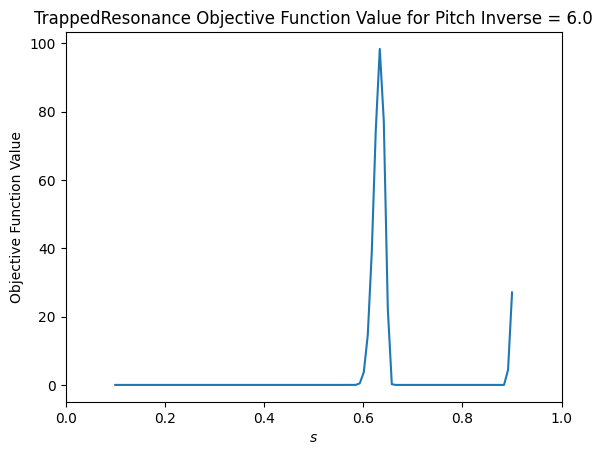

In [12]:
# Plot s vs. obj_out for each pitch inverse
for i in range(0,obj_out.shape[1]): # loop through each pitch angle
    plt.figure(i+1)
    plt.plot(rhos**2,obj_out[:,i,0]) # assuming we are only doing 1 energy for now
    plt.xlabel(r'$s$')
    plt.ylabel('Objective Function Value')
    plt.title('TrappedResonance Objective Function Value for Pitch Inverse = '+str(pitch_invs[i]))
    # plt.ylabel(r'$\omega_{\zeta}$')
    # plt.title(r'$\omega_{\zeta}$ Value for Pitch Inverse = '+str(pitch_invs[i]))
    plt.xlim([0.0,1.0])

In [ ]:
# Plot the value of the TrappedResonance objective (summing over the rho axis) vs. pitch
num_valid_pitch = jnp.sum(obj_out!=0,axis=1)
obj_out_rhosum = np.sum(obj_out,axis=0) / num_valid_pitch # average over rho axis where the obj function is not zero

plt.figure()
plt.plot(pitch_invs,obj_out_rhosum[:,0])
plt.title("TrappedResonance Objective Function Averaged Over All Surfaces")
plt.xlabel("Pitch Inverse [T]")
plt.ylabel("Objective Function Value")

In [ ]:
x=np.array([0,1,2,0])
mask = x!=0
count = jnp.sum(mask,axis=0) # how many wells that are not 0
print(count)